# Определение ориентации текста

**Задача.** По кропу, найденному детектором текста, предсказать вероятность того,
что надпись перевёрнута на 180°. Такой классификатор ставится между детектором
и распознавателем OCR, чтобы передавать распознавателю правильно ориентированный текст.

**Подход.** За основу взята небольшая свёрточная модель PP-LCNet x1.0 с готовыми
весами для ориентации текстовых строк. Она дообучена на словах и строках из HierText
и синтетических надписях. Для каждого изображения созданы обе ориентации.
При предсказании объединяются ответы на исходный и перевёрнутый кроп,
а калибровка корректирует уверенность модели на отдельной части данных.

**Результат:** 0.96611242 по метрике **1 − Brier**, Brier — 0.03388758.
Баллы относятся к сохранённым итоговым весам и файлу
`outputs/submission_calibrated.csv`.

**Как запустить.** После установки окружения по README выберите ядро `.venv/bin/python`
и выполните **Run All**. Ноутбук читает сохранённые результаты эксперимента,
запускает локальный инференс готовой модели и создаёт **`submission.csv` в корне проекта**.
Обучение и подбор температуры при этом не запускаются. Обучающий корпус и
промежуточные прогнозы для этого сценария не нужны.


## 1. Настройки запуска

Веса и калибровка уже находятся в репозитории. Для вычислений на CPU замените
`DEVICE` на `"cpu"`; для повторения GPU-запуска используется `"gpu:0"`.
Размер пачки 256 совпадает с отправленным решением. Все пути задаются относительно
корня проекта, поэтому абсолютные пути с машины автора не требуются.


In [11]:
import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

# Notebook можно открыть из корня проекта или из его подкаталога.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pyproject.toml").is_file() and (p / "src").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Откройте notebook внутри каталога проекта")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.metrics import binary_metrics
from src.inference.submission import compare_submissions, read_sample

DEVICE = "gpu:0"
SEED = 42
BATCH_SIZE = 256
RUN_DIR = ROOT / "outputs/finetune_20260920_175555_827888"
WEIGHTS = RUN_DIR / "best.pdparams"
CALIBRATION = ROOT / "outputs/calibration/finetuned_rotation.json"
TEST_DIR = ROOT / "data/test"
OUTPUT = ROOT / "submission.csv"
REFERENCE = ROOT / "outputs/submission_calibrated.csv"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"Устройство: {DEVICE}; результат: {OUTPUT.name}")


Устройство: gpu:0; результат: submission.csv


In [12]:
def read_json(path):
    """Прочитать сохранённые настройки или результаты эксперимента."""
    return json.loads(Path(path).read_text(encoding="utf-8"))


def file_hash(path):
    """Проверить содержимое файла независимо от его имени и расположения."""
    with Path(path).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


published = read_json(REFERENCE.with_suffix(".json"))
calibration = read_json(CALIBRATION)

# Защищаем связь результата с конкретными весами: случайная подмена файла
# с тем же именем не должна выглядеть как повторение отправленного решения.
if file_hash(WEIGHTS) != published["weights_sha256"]:
    raise ValueError("Выбраны другие веса; нужны веса отправленного решения")
if calibration != published["calibration"]:
    raise ValueError("Настройки калибровки отличаются от отправленного решения")
if file_hash(REFERENCE) != published["output_sha256"]:
    raise ValueError("Изменился сохранённый эталонный CSV")

sample_path = TEST_DIR / "sample_submission.csv"
sample = read_sample(sample_path)  # Проверяет колонки, 20 000 ID и Git LFS-указатель.
if file_hash(sample_path) != published["sample_sha256"]:
    raise ValueError("Используется другой образец тестового ответа")
print(f"Готовы итоговые веса, калибровка и образец для {len(sample):,} изображений")


Готовы итоговые веса, калибровка и образец для 20,000 изображений


## 2. Что именно предсказывает модель

Класс `0` — текст в нормальной ориентации, класс `1` — поворот на 180°.
В CSV записывается **вероятность класса `1`**, а не метка после порога 0.5.
Значение 0.9 означает высокую уверенность, что текст перевёрнут.

Основная метрика оценивает и правильность ответа, и уверенность:

$$\operatorname{Brier}=\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2,
\qquad \operatorname{score}=1-\operatorname{Brier}.$$

Идеальное значение score равно 1. Для постоянного прогноза 0.5 Brier равен 0.25,
а score — 0.75. Accuracy дополнительно показывает долю верных решений, но сама
по себе не описывает качество вероятностей.


In [13]:
# Маленький пример проверяет определение метрики, а не оценивает модель.
display(pd.DataFrame([binary_metrics([0, 1], [0.5, 0.5])]).round(6))


,n,brier,score,log_loss,accuracy
0,2,0.25,0.75,0.693147,0.5


## 3. Данные и разделение

По условию обучающая выборка не предоставлена. Использованы внешние данные:

- **HierText validation:** 66 271 выпрямленный кроп слова или строки.
  Отбираются читаемые печатные надписи с подходящей геометрией.
- **Синтетика:** 4 000 изображений, из них 3 000 с кириллицей и 1 000 с латиницей.
  Тексты отрисовываются шрифтами DejaVu с изменением размера, контраста,
  размытием, шумом и JPEG-искажениями.

Для каждого нормального кропа создаётся поворот на 180° — так получаются две
метки без ручной разметки теста. Обе ориентации остаются в одной части данных.
Сначала объединяются найденные дубликаты, затем группы сцен разделяются
с seed **42**. Пропорции 70/10/10/10 заданы по группам, поэтому доли кропов отличаются.

| Часть | Кропов | Примеров 0°/180° | Использование |
| --- | ---: | ---: | --- |
| Train | 48 743 | 97 486 | Обновление весов |
| Development | 7 155 | 14 310 | Выбор модели и способа предсказания |
| Calibration | 7 248 | 14 496 | Настройка уверенности выбранной модели |
| Holdout | 7 125 | 14 250 | Оценка зафиксированного решения |

Это собственное разделение внешнего корпуса. Оно не является официальным
разделением бенчмарка HierText. RusTitW реализован как дополнительный источник,
но в итоговом обучении не использовался.

Ниже — несколько **неразмеченных тестовых кропов** для иллюстрации входных данных.
Они не используются для обучения или выбора настроек; метки им вручную не назначаются.


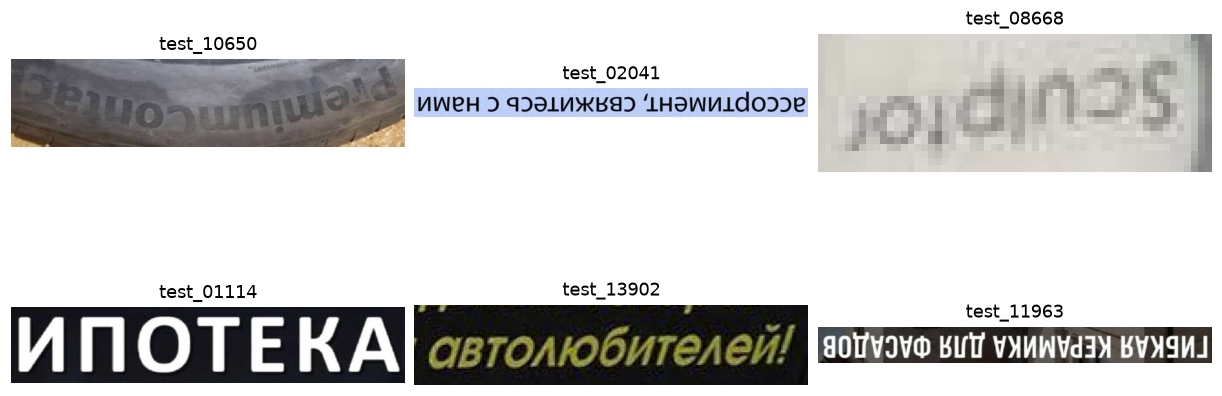

In [14]:
# Фиксированный seed делает подбор иллюстраций воспроизводимым.
# У примеров показан только ID: правильные ответы для теста неизвестны.
examples = sample.sample(n=6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(11, 4.4), layout="constrained")

for ax, image_id in zip(axes.flat, examples.image_id, strict=True):
    path = TEST_DIR / "test/images" / f"{image_id}.png"
    with Image.open(path) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(image_id)
    ax.axis("off")
plt.show()


## 4. Почему выбрана эта модель

PP-LCNet x1.0 — свёрточная сеть с разделёнными по каналам свёртками.
Она выбрана как компактная основа для большого потока небольших текстовых кропов.
Начальные веса уже специализированы на ориентации строк, что позволяет ограничиться
коротким дообучением вместо обучения с нуля.

Изображение читается в **RGB**, приводится к размеру **160 × 80**, нормализуется
статистиками ImageNet и подаётся в формате CHW. Общая подготовка для оценки
и инференса вынесена в `src/data/preprocessing.py`. Вычисления выполняются в FP32.

Сравниваются два способа предсказания:

- **Single:** один проход модели.
- **Rotation:** исходное изображение и поворот на 180°. Для второго ответа
  меняется смысл класса, поэтому используется дополнение `1 − p`:

$$q(x)=\frac{p(x)+1-p(\operatorname{rot180}(x))}{2}.$$

Это обеспечивает согласованность пары: $q(\operatorname{rot180}(x))=1-q(x)$.
Цена — два прохода вместо одного. Режим выбран по сравнению качества на development;
время его работы измеряется отдельно при получении CSV.


## 5. Как проходило дообучение

Сохранённый итоговый запуск стартовал с исходных специализированных весов:
6 эпох, batch size 256, начальный LR 0.001, функция потерь — cross-entropy.
Параметры запуска сохранены в `config.json` рядом с весами. Для каждого
обучающего кропа использованы нормальная ориентация и поворот на 180°.

**В отправленном запуске выбрана эпоха 4 по минимальной cross-entropy на всём
development.** Ниже читается её настоящая история из репозитория.
После дообучения режимы single/rotation сравнивались по целевой метрике Brier.


,epoch,train_loss,development_loss,development_accuracy
0,1,0.231124,0.093256,0.957582
1,2,0.074225,0.082564,0.964640
2,3,0.051682,0.079646,0.965409
3,4,0.038044,0.079039,0.967086
4,5,0.028810,0.081962,0.967226
5,6,0.025041,0.081506,0.967855


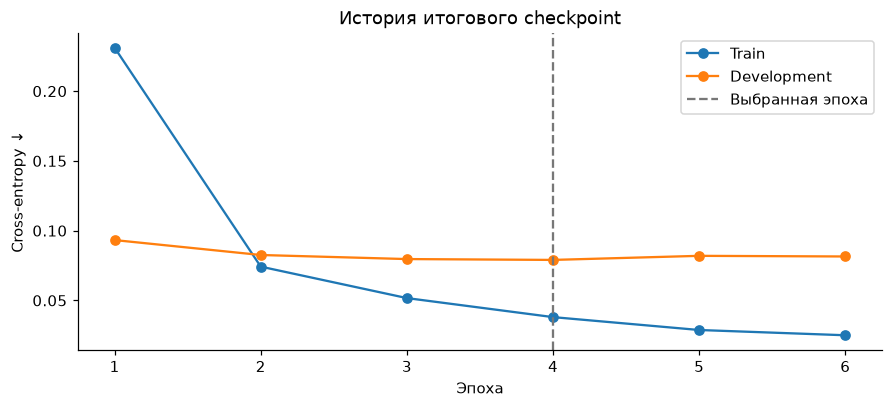

In [15]:
history = pd.DataFrame(read_json(RUN_DIR / "history.json"))
best = read_json(RUN_DIR / "best.json")
columns = ["epoch", "train_loss", "development_loss", "development_accuracy"]
display(history[columns].round(6))

# Обе кривые — одна и та же функция потерь на разных частях данных.
# Продолжение уменьшения train loss само по себе не делает модель лучше.
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
ax.plot(history.epoch, history.train_loss, "o-", label="Train")
ax.plot(history.epoch, history.development_loss, "o-", label="Development")
ax.axvline(best["epoch"], color="#777777", linestyle="--", label="Выбранная эпоха")
ax.set(xlabel="Эпоха", ylabel="Cross-entropy ↓", title="История итогового checkpoint")
ax.legend()
plt.show()


Отдельный последующий запуск через `src.training.train` выбирал веса по Brier
на реальном development. Его лучший результат — 0.02217974 против 0.02077580
у сохранённой итоговой модели в режиме rotation. Для сабмишена оставлены прежние
веса. Повторять тот запуск для выполнения этого notebook не требуется.


## 6. Сравнение подходов

Таблица строится по сохранённым отчётам: пересчёт прогнозов или наличие
обучающего корпуса для её просмотра не требуются. Для основного сравнения
используются реальные кропы development. Синтетические примеры показаны отдельно,
чтобы их более высокое качество не скрывало ошибки на реальных изображениях.


,model,source,variant,n,brier,score,accuracy
0,Исходная,real,rotation,13518,0.155934,0.844066,0.958278
1,Исходная,real,single,13518,0.308080,0.691920,0.644844
2,Исходная,synthetic,rotation,792,0.083618,0.916382,0.896465
3,Исходная,synthetic,single,792,0.128757,0.871243,0.838384
4,Дообученная,real,rotation,13518,0.020776,0.979224,0.972925
5,Дообученная,real,single,13518,0.024721,0.975279,0.965601
6,Дообученная,synthetic,rotation,792,0.005592,0.994408,0.989899
7,Дообученная,synthetic,single,792,0.007179,0.992821,0.992424


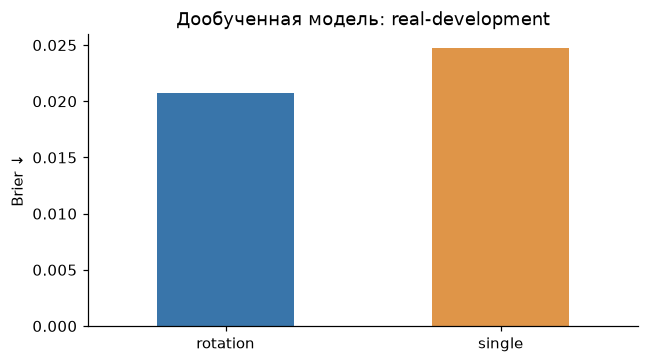

In [16]:
evaluation_root = ROOT / "outputs/evaluation"
parts = []
for directory, name in [("pretrained_development", "Исходная"),
                        ("finetuned_development", "Дообученная")]:
    report = read_json(evaluation_root / directory / "report.json")
    if report["manifest_sha256"] != calibration["manifest_sha256"]:
        raise ValueError("Нельзя сравнивать отчёты, полученные на разных корпусах")
    if directory == "finetuned_development" and report["weights_sha256"] != published["weights_sha256"]:
        raise ValueError("Оценка development относится к другим весам")
    metrics = pd.read_csv(evaluation_root / directory / "metrics.csv")
    parts.append(metrics.assign(model=name))

comparison = pd.concat(parts, ignore_index=True)
display(comparison[["model", "source", "variant", "n", "brier", "score", "accuracy"]].round(8))

# Сравниваем single и rotation для итоговых весов при одинаковых данных.
real = comparison.loc[comparison.source.eq("real") & comparison.model.eq("Дообученная")]
ax = real.set_index("variant").brier.plot.bar(
    figsize=(6, 3.4), rot=0, color=["#3975aa", "#df9548"]
)
ax.set(xlabel="", ylabel="Brier ↓", title="Дообученная модель: real-development")
plt.tight_layout()
plt.show()


На реальном development объединение ориентаций уменьшило Brier с **0.02472064**
до **0.02077580**. Поэтому для итогового инференса выбран rotation.

## 7. Калибровка и итоговая проверка

Правильный класс и правильная уверенность — разные задачи. Модель может часто
угадывать ориентацию, но быть чрезмерно уверенной в ошибках. Температурная
калибровка меняет уверенность, сохраняя решение при пороге 0.5:

$$p_{180}=\operatorname{sigmoid}(\operatorname{logit}(q)/T).$$

Температура применяется **после объединения двух ориентаций**. Значение
`T ≈ 1.139` подобрано по Brier только на реальных кропах calibration.
Сейчас читается готовая настройка; повторной оптимизации температуры нет.
Метрики before/after на calibration описывают данные подбора, поэтому не являются
независимым доказательством улучшения.


In [17]:
calibration_metrics = pd.DataFrame({
    "До калибровки": calibration["before"],
    "После калибровки": calibration["after"],
}).T
print(f"Температура: {calibration['temperature']:.8f}")
display(calibration_metrics[["n", "brier", "score", "accuracy"]].round(8))

# Holdout оценивается с уже выбранными весами, режимом и температурой.
# Читаем итоговые числа; по ним здесь ничего не подбирается.
holdout_report = read_json(evaluation_root / "finetuned_holdout/report.json")
if holdout_report["weights_sha256"] != published["weights_sha256"]:
    raise ValueError("Оценка holdout относится к другим весам")
if holdout_report["manifest_sha256"] != calibration["manifest_sha256"]:
    raise ValueError("Оценка holdout относится к другому корпусу")
if holdout_report["temperature"] != calibration["temperature"]:
    raise ValueError("На holdout использована другая температура")

holdout = pd.read_csv(evaluation_root / "finetuned_holdout/metrics.csv")
display(holdout[["source", "crops", "n", "brier", "score", "accuracy"]].round(8))


Температура: 1.13908186


,n,brier,score,accuracy
До калибровки,13686.0,0.02258,0.97742,0.969019
После калибровки,13686.0,0.02252,0.97748,0.969019


,source,crops,n,brier,score,accuracy
0,real,6750,13500,0.026281,0.973719,0.964593
1,synthetic,375,750,0.003391,0.996609,0.997333


На реальной части holdout получен score **0.97371928**. На лидерборде —
**0.96611242**. Это разные наборы изображений; совпадения метрик ожидать не следует.
Holdout уже просмотрен, поэтому при дальнейших экспериментах его нельзя считать
ранее не исследованной выборкой.

## 8. Получение `submission.csv`

Следующая ячейка запускает существующий модуль инференса с итоговыми весами
и калибровкой. Вычисления происходят локально, без внешних API. Каждый тестовый
кроп действительно проходит через модель; сохранённый CSV не подставляется
вместо нового предсказания.

Пересоздаются только `submission.csv` и `submission.json` в корне проекта.
Флаг `--overwrite` позволяет повторно выполнить ячейку. Обученные веса,
калибровка и отправленный CSV в `outputs/` при этом сохраняются.


In [18]:
# Используем тот же CLI, что и при получении отправленного результата.
# Отдельный процесс освобождает память модели после инференса.
command = [
    sys.executable, "-u", "-m", "src.inference.predict",
    "--weights", str(WEIGHTS), "--calibration", str(CALIBRATION),
    "--test-dir", str(TEST_DIR), "--device", DEVICE,
    "--batch-size", str(BATCH_SIZE), "--read-workers", "8",
    "--output", str(OUTPUT), "--overwrite",
]
print("Запущен инференс итоговой модели…", flush=True)
completed = subprocess.run(command, cwd=ROOT, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, text=True)
if completed.returncode:
    print(completed.stdout)
    completed.check_returncode()

# Показываем итог запуска без длинного журнала обновлений progress bar.
for line in completed.stdout.splitlines():
    if line.startswith(("Режим:", "Строк:", "PNG -> CSV:", "CSV готов:")):
        print(line)


Запущен инференс итоговой модели…
Режим: rotation; температура: 1.13908186
Строк: 20000; порядок ID: OK; вероятности: OK
PNG -> CSV: 17.50 с; 1142.7 кропов/с
CSV готов: /home/user-21/projects/avito-bootcamp-final/submission.csv


## 9. Проверка формата и воспроизведения

По ТЗ файл должен содержать ровно две колонки — `image_id` и `p_180` —
и все 20 000 тестовых изображений. Вероятности должны быть конечными числами
в диапазоне от 0 до 1, а порядок ID соответствовать образцу.

Дополнительно сравниваем полученный файл с отправленным: отдельно байты CSV
и сами вероятности. Это позволяет отличить изменение форматирования от изменения
ответов модели. Различия не округляются дополнительно и не заменяются эталоном.
Окончательная проверка побайтового совпадения выполняется именно этой ячейкой;
она не предполагается заранее для другого оборудования или окружения.


In [19]:
current_report = read_json(OUTPUT.with_suffix(".json"))
for key in ("weights_sha256", "sample_sha256", "variant", "temperature", "preprocessing"):
    if current_report[key] != published[key]:
        raise ValueError(f"Настройки нового запуска отличаются: {key}")
if current_report["output_sha256"] != file_hash(OUTPUT):
    raise ValueError("CSV изменился после сохранения отчёта")

# Общие проверки вынесены в src/inference/submission.py.
# Здесь нет тестовых меток: сравнение файлов не является оценкой Brier.
check = compare_submissions(OUTPUT, REFERENCE, sample)
display(pd.DataFrame([check]))
display(pd.read_csv(OUTPUT).head())

if check["identical_bytes"]:
    print("Полученный submission.csv побайтово совпадает с отправленным")
elif check["different_probabilities"] == 0:
    print("Вероятности совпадают; отличается только представление CSV")
else:
    print(f"Вероятности различаются: максимум |Δp| = {check['max_absolute_difference']:.3g}")
    print("Проверьте устройство и окружение; новый CSV не выдаётся за точную копию отправленного")
print(f"Файл для сдачи: {OUTPUT}")


,rows,identical_bytes,different_probabilities,max_absolute_difference,mean_absolute_difference
0,20000,True,0,0.0,0.0


,image_id,p_180
0,test_00000,0.001556
1,test_00001,0.999930
2,test_00002,0.999797
3,test_00003,0.018130
4,test_00004,0.993794


Полученный submission.csv побайтово совпадает с отправленным
Файл для сдачи: /home/user-21/projects/avito-bootcamp-final/submission.csv


## 10. Скорость и компактность

По условию при близком качестве важны скорость и размер модели. В сохранённом
запуске на **RTX 6000 Ada** обработка 20 000 кропов заняла **17.357 с**.
В замер входят чтение PNG, подготовка входов, оба прохода модели, калибровка
и запись CSV. Загрузка весов и прогрев исключены. Batch size — 256,
потоков чтения — 8; среднее время ниже характеризует пакетную обработку,
а не задержку отдельного запроса.

Следующая таблица показывает прежнее измерение и результат текущего запуска.
Размер файла весов характеризует хранение модели и не равен её потреблению RAM/VRAM.


In [20]:
timings = []
for name, report in [("Отправленный запуск, RTX 6000 Ada", published),
                     (f"Текущий запуск, {current_report['device']}", current_report)]:
    seconds = report["png_to_csv_seconds"]
    timings.append({"запуск": name, "кропов": report["rows"], "секунд": seconds,
                    "кропов/с": report["rows"] / seconds if seconds > 0 else np.nan,
                    "мс/кроп в пачке": 1000 * seconds / report["rows"]})
display(pd.DataFrame(timings).round(3))
print(f"Размер итогового файла весов: {WEIGHTS.stat().st_size / 2**20:.2f} MiB")


,запуск,кропов,секунд,кропов/с,мс/кроп в пачке
0,"Отправленный запуск, RTX 6000 Ada",20000,17.357,1152.273,0.868
1,"Текущий запуск, gpu:0",20000,17.502,1142.727,0.875


Размер итогового файла весов: 6.44 MiB


## 11. Выводы, ограничения и используемые источники

Короткое дообучение улучшило качество исходной модели. Объединение двух
ориентаций дополнительно снизило Brier на реальном development. Температура
настроена на отдельной части данных. Итоговый score на лидерборде — **0.96611242**
против **0.95800658** у предыдущего отправленного CSV. Отдельный эффект одной
только температуры на лидерборде не измерялся.

Главное ограничение — мало реальной кириллицы: все 50 чисто кириллических
реальных кропов оказались в train, а в остальных частях есть лишь единичные
смешанные тексты. Высокие результаты на синтетике не подтверждают такое же
качество на реальных русскоязычных надписях. Группировка по хешам уменьшает
пересечения, но не гарантирует обнаружение всех сложных дубликатов.

Дальнейшее улучшение требует отдельной проверки реальных русскоязычных данных
и качества их разметки. Добавление RusTitW возможно, но в описанный результат
не входит. По тестовым изображениям настройки не подбираются, ручная разметка
теста не используется. В итоговом решении нет LLM/VLM и обращений к внешним API;
для инференса достаточно локальных файлов репозитория и установленного окружения.

| Компонент | Источник и использование |
| --- | --- |
| PP-LCNet x1.0 | [PaddleClas](https://github.com/PaddlePaddle/PaddleClas), адаптация архитектуры в `src/models/lcnet.py`; уведомление Apache-2.0 сохранено |
| Начальные веса | Официальные веса `PP-LCNet_x1_0_textline_ori_pretrained.pdparams`; адрес загрузки указан в [src/models/weights.py](src/models/weights.py) |
| Реальные надписи | [HierText](https://github.com/google-research-datasets/hiertext), архив validation; CC-BY-SA-4.0 |
| Синтетические надписи | Генератор проекта и шрифты [DejaVu](https://dejavu-fonts.github.io/); шрифты и их лицензия скачиваются при подготовке |
| Вычисления и обработка | PaddlePaddle, NumPy, OpenCV, Pillow, pandas, SciPy; графики — Matplotlib. Окружение зафиксировано в `uv.lock` |

Код подготовки, модели, оценки и инференса разделён по модулям в `src/`.
Этот notebook объясняет эксперимент и воспроизводит предсказания сохранённой
модели; он не запускает повторное обучение при проверке решения.
